In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression #이진 분류
from sklearn.metrics import accuracy_score

In [8]:
churn_df = pd.read_csv("datasets/ChurnData.csv")

In [9]:
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [13]:
A = np.array(churn_df.values)
A.shape

(200, 28)

In [15]:
columns = churn_df.columns[:-1]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
columns.size

27

In [17]:
x_2 = churn_df.iloc[:,:columns.size] #열 인덱스로 선택
x = churn_df.loc[:,columns] #열 이름으로 선택
y = churn_df['churn']
x_2.shape, x.shape

((200, 27), (200, 27))

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0) #학습용/검증용 따로 나눠서 테스트
#x_train : 학습용 입력 데이터, x_test : 테스트용 입력 데이터, y_train : 학습용 정답 데이터, y_test : 테스트용 정답 데이터

In [21]:
sc = StandardScaler() #표준화 : 모든 특성의 평균=0, 표준편차 =1로 맞춤, 스케일러 객체 생성
x_train = sc.fit_transform(x_train) #fit(데이터:평균, 표준편차 계산)->transform = (같은 결과)
x_test = sc.transform(x_test) #학습 데이터 변환

In [23]:
print(x_train.shape)
print(x_test.shape)

(160, 27)
(40, 27)


In [25]:
clf = LogisticRegression() #결과가 일어날 확률 예측 모델
clf.fit(x_train, y_train)

LogisticRegression()

In [27]:
y_pred = clf.predict(x_test) #예측값 반환(0 또는 1 클래스)
score_v = clf.score(x_test, y_test) #정확도 계산
accuracy_score(y_test, y_pred), score_v #모델이 Classifier일때만 결과과 같게 나옮
#accuracy_score : 직접 계산
#score : 모델 내장 평가 함수, 자동으로 accuracy_score() 호출

(0.775, 0.775)

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [55]:
print("차원 축소된 x_train : ", x_train_pca.shape)
print("차원 축소된 x_test : ", x_test_pca.shape)

차원 축소된 x_train :  (160, 2)
차원 축소된 x_test :  (40, 2)


In [57]:
print(pca.components_.shape)
print("첫번째 주성분(고유벡터) : ")
print(pca.components_[0])
print("두번째 주성분(고유벡터) : ")
print(pca.components_[1])
print()
print('설명된 분산(고유값)의 비율 : {}, 두 성분의 합 : {:.2f}'.format(pca.explained_variance_ratio_, sum(pca.explained_variance_ratio_)))

(2, 27)
첫번째 주성분(고유벡터) : 
[0.18870382 0.09407626 0.06999421 0.02405283 0.08039882 0.10532452
 0.0913006  0.22012759 0.24022929 0.17035807 0.26783154 0.16389682
 0.25017627 0.28326203 0.17638143 0.27435707 0.22993114 0.24062665
 0.26112415 0.0747603  0.22729268 0.21587761 0.06959358 0.17457864
 0.17900112 0.07082588 0.29324012]
두번째 주성분(고유벡터) : 
[ 0.2917276   0.18411246  0.24507417  0.04409899 -0.16349343  0.2142686
 -0.23252316  0.07599265 -0.23520159  0.29224485 -0.06742566 -0.24108039
  0.12944092 -0.20861384  0.29806582  0.04425842  0.22376079 -0.18866967
 -0.17737835 -0.24830636 -0.0674659  -0.05215805 -0.21541163  0.28738933
  0.03136523  0.07488121 -0.10196478]

설명된 분산(고유값)의 비율 : [0.25193472 0.21764464], 두 성분의 합 : 0.47


In [69]:
clf = LogisticRegression(solver='lbfgs', random_state=0)
clf.fit(x_train_pca, y_train)

LogisticRegression(random_state=0)

In [73]:
y_pred = clf.predict(x_test_pca)
y_pred

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0.])

In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.725

In [77]:
x_train_pca.shape

(160, 2)

In [79]:
x_train_pca[y_train == 0][:5]

array([[-1.79076917,  2.66110381],
       [-0.61237011,  2.69921328],
       [ 3.14274902,  4.7126509 ],
       [ 0.83536207,  2.1831414 ],
       [-1.00524582,  0.30330428]])

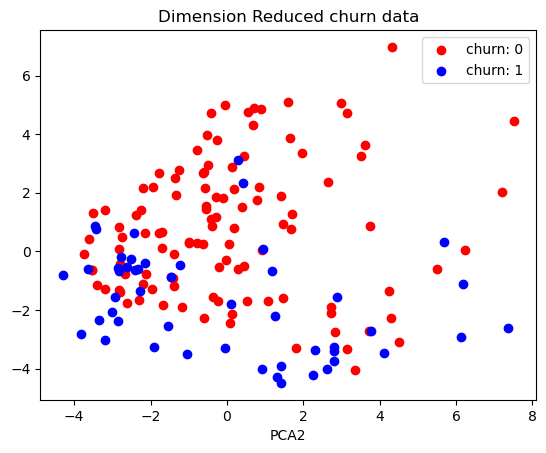

In [89]:
x1, x2 = x_train_pca[y_train == 0,0], x_train_pca[y_train == 0,1]
plt.scatter(x1, x2, color='r', label="churn: 0")

x1, x2 = x_train_pca[y_train == 1,0], x_train_pca[y_train == 1,1]
plt.scatter(x1, x2, color='b', label="churn: 1")

plt.xlabel('PCA1')
plt.xlabel('PCA2')
plt.legend()
plt.title('Dimension Reduced churn data')
plt.show()